In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

# 가상 시계열 데이터 생성

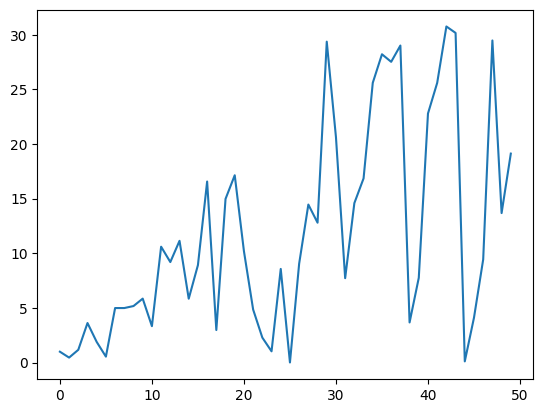

In [2]:
list_a = np.random.rand(50)
list_a = [(idx + 1) * val for idx, val in enumerate(list_a)]
plt.plot(list_a)
plt.show()

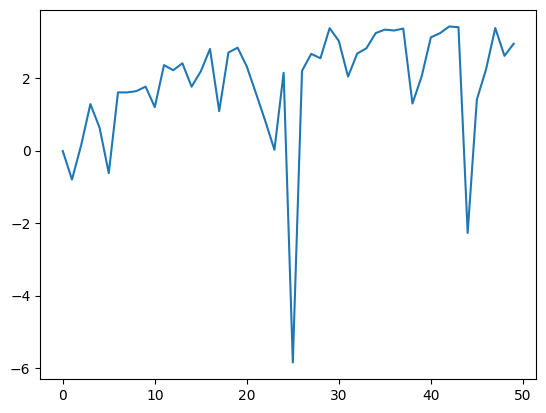

In [3]:
# 로그를 활용한 계절성, 추세 제거
list_a = np.log(list_a)
plt.plot(list_a)
plt.show()

In [5]:
import numpy as np

list_a = [1, 2, 3, 4, 5]
print(list_a)
print(np.diff(list_a)) # 차분을 활용하여 분산을 일정하게 만듬

[1, 2, 3, 4, 5]
[1 1 1 1]


# 로그와 차분을 결합

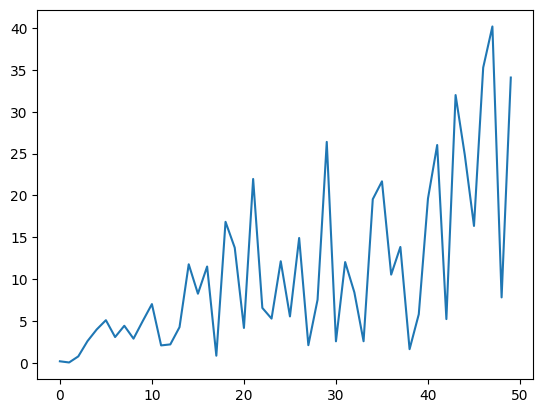

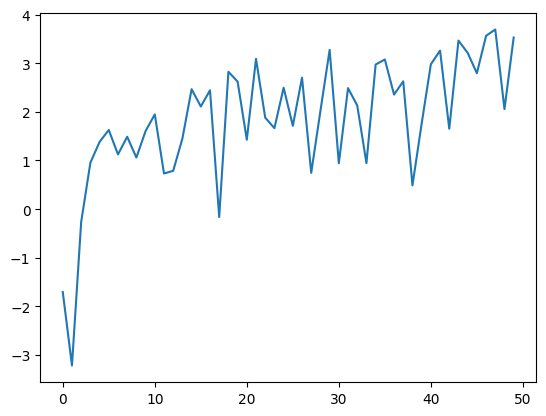

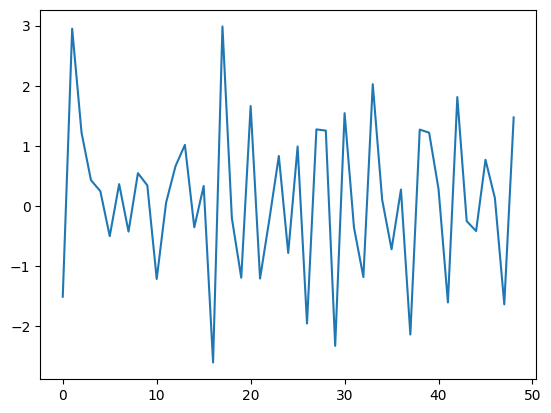

In [7]:
list_a = np.random.rand(50)
list_a = [(idx + 1) * val for idx, val in enumerate(list_a)]
plt.plot(list_a)
plt.show()

list_a = np.log(list_a)
plt.plot(list_a)
plt.show()

list_a = np.diff(list_a)
plt.plot(list_a)
plt.show()

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv('../CSV/daily-total-female-births-CA.csv')
df.head()

,date,births
0,1959-01-01,35
1,1959-01-02,32
2,1959-01-03,30
3,1959-01-04,31
4,1959-01-05,44


In [12]:
timestamp = df.births

In [18]:
def SMA(array, window):
    array = np.array(array)
    assert array.ndim == 1, "1차원 array만 입력할 수 있습니다."
    n = len(array)

    result = np.empty(n)
    result[:] = np.nan

    ma = []

    for i in range(0, n - window + 1):
        m = np.mean(array[i : i + window])
        ma.append(m)

    result[window - 1:] = ma

    return np.array(result)

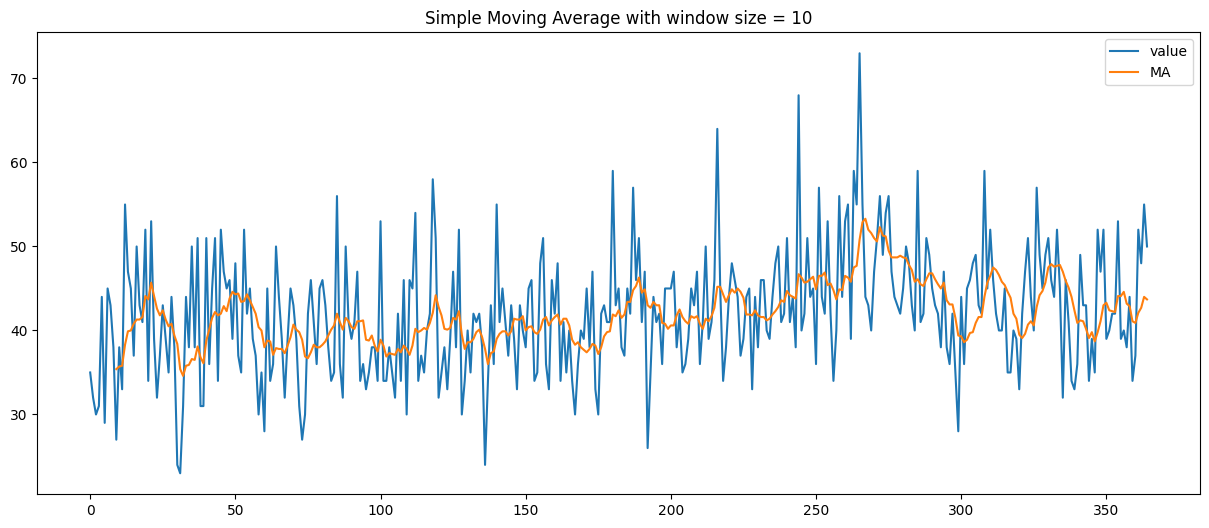

In [19]:
window = 10

sma = SMA(timestamp, window)

timestamp.plot(figsize = (15, 6))
plt.plot(sma)
plt.legend(['value', 'MA'])
plt.title('Simple Moving Average with window size = {}'.format(window))
plt.show()

# 시계열 데이터 결측값을 보간법 채우는 예시

In [20]:
import pandas as pd
import numpy as np

data = {
    'A': [1, 2, np.nan, 4, 5],
    'B': [5, np.nan, np.nan, 8, 9],
    'C': [9, 10, 11, 12, 13]
}

df = pd.DataFrame(data)
print(df)

     A    B   C
0  1.0  5.0   9
1  2.0  NaN  10
2  NaN  NaN  11
3  4.0  8.0  12
4  5.0  9.0  13


In [21]:
df_interpolated = df.interpolate() # method = 'linear' 디폴트
print(df_interpolated)

     A    B   C
0  1.0  5.0   9
1  2.0  6.0  10
2  3.0  7.0  11
3  4.0  8.0  12
4  5.0  9.0  13


In [22]:
df_interpolated2 = df['A'].interpolate()
print(df_interpolated2)

0    1.0
1    2.0
2    3.0
3    4.0
4    5.0
Name: A, dtype: float64


In [24]:
df_interpolated = df.interpolate(method = 'polynomial', order = 1)
print(df_interpolated)

     A    B   C
0  1.0  5.0   9
1  2.0  6.0  10
2  3.0  7.0  11
3  4.0  8.0  12
4  5.0  9.0  13


In [27]:
df_interpolated = df.interpolate(methon = 'linear', limit = 1) # 선형 보간법
print(df_interpolated)

     A    B   C
0  1.0  5.0   9
1  2.0  6.0  10
2  3.0  NaN  11
3  4.0  8.0  12
4  5.0  9.0  13


In [25]:
df_interpolated = df.interpolate(methon = 'linear', limit = 1, limit_direction = 'backward')
print(df_interpolated)

     A    B   C
0  1.0  5.0   9
1  2.0  NaN  10
2  3.0  7.0  11
3  4.0  8.0  12
4  5.0  9.0  13


In [26]:
df_interpolated = df.interpolate(methon = 'slinear', order = 1) # 스플라인 기법
print(df_interpolated)

     A    B   C
0  1.0  5.0   9
1  2.0  6.0  10
2  3.0  7.0  11
3  4.0  8.0  12
4  5.0  9.0  13


In [28]:
import numpy as np
from pandas import DataFrame, Series
from datetime import datetime

datestrs = ['12/1/2016', '12/04/2016', '12/05/2016', '12/10/2016']
dates = pd.to_datetime(datestrs)
dates

DatetimeIndex(['2016-12-01', '2016-12-04', '2016-12-05', '2016-12-10'], dtype='datetime64[ns]', freq=None)

In [30]:
ts = Series([1, np.nan, np.nan, 10], index = dates)

In [33]:
ts

2016-12-01     1.0
2016-12-04     NaN
2016-12-05     NaN
2016-12-10    10.0
dtype: float64

In [32]:
ts_intp_linear = ts.interpolate()
ts_intp_linear

2016-12-01     1.0
2016-12-04     4.0
2016-12-05     7.0
2016-12-10    10.0
dtype: float64

In [34]:
ts_intp_time = ts.interpolate(method = 'time')
ts_intp_time

2016-12-01     1.0
2016-12-04     4.0
2016-12-05     5.0
2016-12-10    10.0
dtype: float64

# prophet

In [35]:
df = pd.read_csv('../CSV/AAPL.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.100323,469033600
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095089,175884800
2,1980-12-16,0.113281,0.113281,0.112723,0.112723,0.088110,105728000
3,1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090291,86441600
4,1980-12-18,0.118862,0.119420,0.118862,0.118862,0.092908,73449600


In [36]:
df['ds'] = df['Date'] # 날짜 데이터 ds 이름 저장
df['y'] = df['Close'] # 타켓은 y로 저장

In [37]:
data = df[['ds', 'y']]
data = data[-1000:]
data.head()

,ds,y
9409,2018-04-06,42.095001
9410,2018-04-09,42.512501
9411,2018-04-10,43.312500
9412,2018-04-11,43.110001
9413,2018-04-12,43.535000


In [41]:
from prophet import Prophet

prophet_m = Prophet().fit(data)

10:44:55 - cmdstanpy - INFO - Chain [1] start processing
10:44:56 - cmdstanpy - INFO - Chain [1] done processing


In [43]:
future = prophet_m.make_future_dataframe(periods = 365)
future.tail()

,ds
1360,2023-03-20
1361,2023-03-21
1362,2023-03-22
1363,2023-03-23
1364,2023-03-24


In [44]:
forecast = prophet_m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1360,2023-03-20,203.235916,158.425909,253.665324
1361,2023-03-21,203.599460,156.167147,253.860055
1362,2023-03-22,203.830865,158.092345,254.978729
1363,2023-03-23,203.785625,156.117735,255.046372
1364,2023-03-24,203.701564,157.558750,255.137135


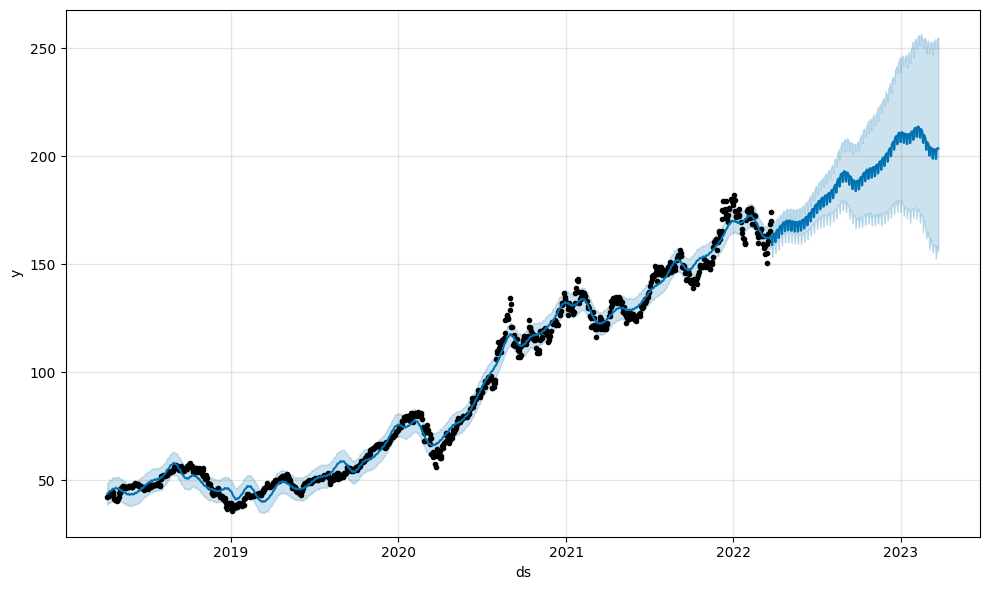

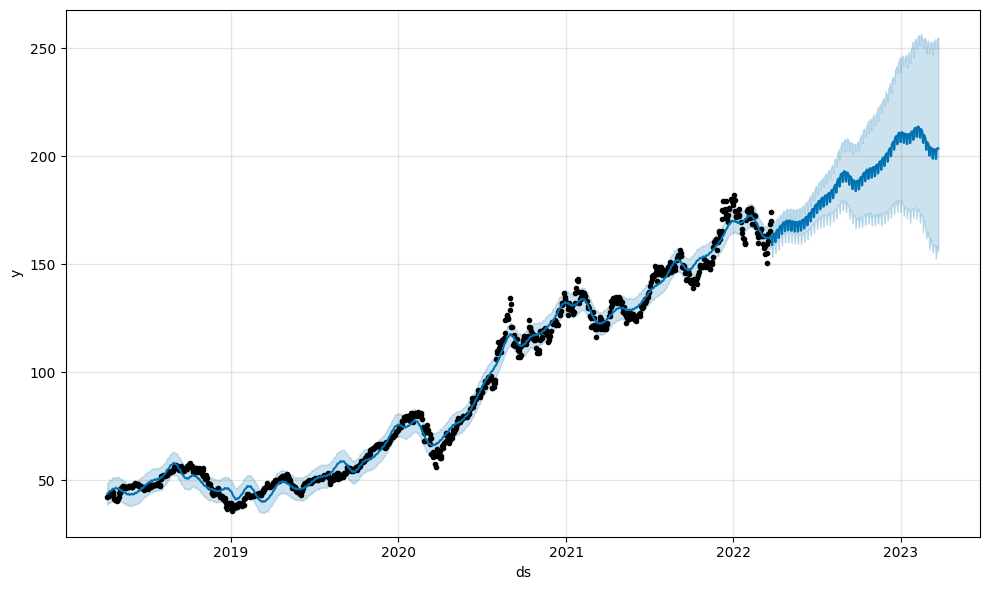

In [45]:
prophet_m.plot(forecast)

# 자동차 판매량 데이터
- 추세(trends)와 계절성(seasonality)을 모두 포함하는 일변량(univariate) 시계열 데이터
- 총 108개월

In [53]:
import pandas as pd

path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv'
df = pd.read_csv(path, header = 0)
print(df.shape)
print(df.head())

(108, 2)
     Month  Sales
0  1960-01   6550
1  1960-02   8728
2  1960-03  12026
3  1960-04  14395
4  1960-05  14587


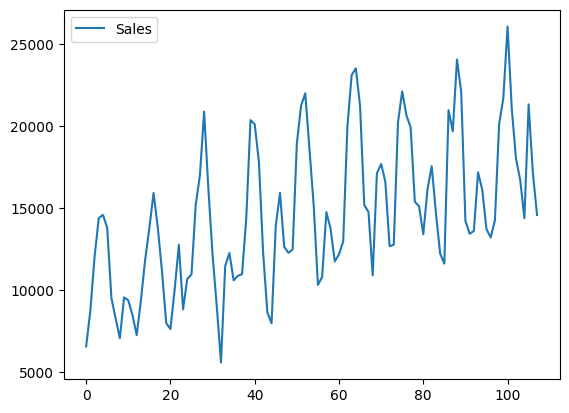

In [54]:
from matplotlib import pyplot

df.plot()
pyplot.show()

In [55]:
df.columns = ['ds', 'y']
df['df'] = pd.to_datetime(df['ds'])
df.tail()

,ds,y,df
103,1968-08,16722,1968-08-01
104,1968-09,14385,1968-09-01
105,1968-10,21342,1968-10-01
106,1968-11,17180,1968-11-01
107,1968-12,14577,1968-12-01


In [56]:
from prophet import Prophet

model = Prophet()
model.fit(df)

11:10:14 - cmdstanpy - INFO - Chain [1] start processing
11:10:14 - cmdstanpy - INFO - Chain [1] done processing


In [61]:
last_1year = list()
for i in range(1, 13):
    last_1year.append(['1968-%02d' % i])

last_1year = pd.DataFrame(last_1year, columns = ['ds'])
last_1year['ds'] = pd.to_datetime(last_1year['ds'])

In [62]:
forecast = model.predict(last_1year)

In [63]:
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='object')

In [64]:
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

          ds          yhat    yhat_lower    yhat_upper
0 1968-01-01  14365.838146  12827.802369  15915.428312
1 1968-02-01  14940.305749  13272.531362  16447.694536
2 1968-03-01  20882.028850  19236.656935  22472.334858
3 1968-04-01  22900.416536  21273.403201  24409.004320
4 1968-05-01  24201.080202  22572.615756  25826.137002


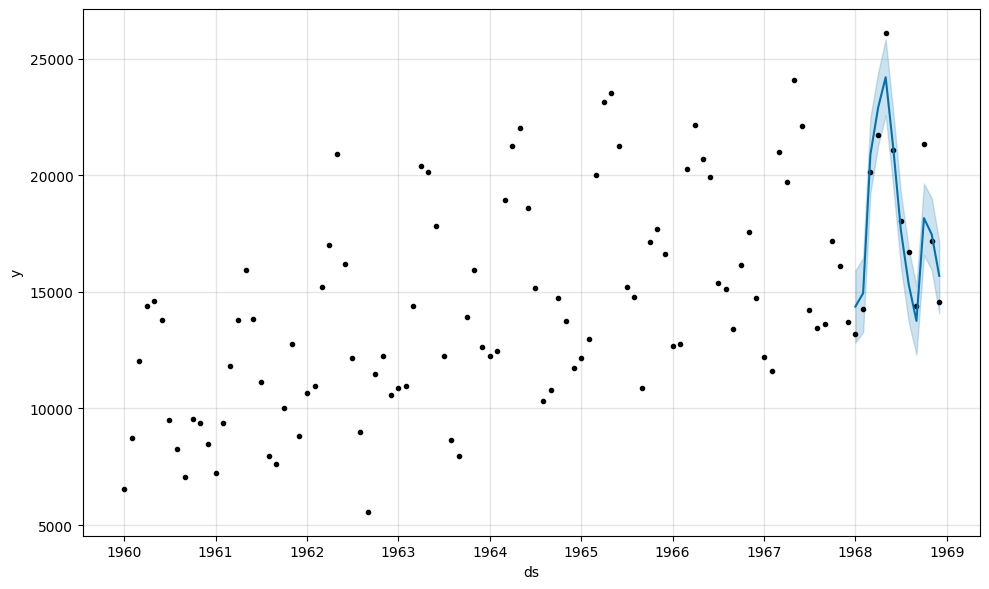

In [65]:
model.plot(forecast)
pyplot.show()

In [67]:
last_1year = list()
for i in range(1, 13):
    last_1year.append(['1969-%02d' % i])

last_1year = pd.DataFrame(last_1year, columns = ['ds'])
last_1year['ds'] = pd.to_datetime(last_1year['ds'])

In [68]:
forecast = model.predict(last_1year)

용어정리
- ds : 날짜 및 시간 정보를 나타내는 열입니다.
- trend : 전반적인 추세를 나타내는 열로, 시간에 따른 데이터의 일반적인 증감 추이를 나타냅니다.
- yhat_lower : 예측 값의 최소 하한선(lower bound)을 나타내는 열입니다.
- yhat_upper : 예측 값의 최대 상한선(upper bound)을 나타내는 열입니다.
- trend_lower, trend_upper : 추세의 최소 및 최대 경계를 나타내는 열입니다.
- additive_terms : 일일, 주간, 연간 등의 추가적인 성분을 나타내는 열입니다.
- additive_terms_lower, additive_terms_upper : 추가적인 성분의 최소 및 최대 경계를 나타내는 열입니다.
- daily, daily_lower, daily_upper: 일일 성분에 대한 값과 그 최소 및 최대 경계를 나타내는 열입니다.
- weekly, weekly_lower, weekly_upper: 주간 성분에 대한 값과 그 최소 및 최대 경계를 나타내는 열입니다.
- yearly, yearly_lower, yearly_upper: 연간 성분에 대한 값과 그 최소 및 최대 경계를 나타내는 열입니다.
- multiplicative_terms, multiplicative_terms_lower, multiplicative_terms_upper : 곱셈 항(multiplicative term)에 대한 값과 그 최소 및 최대 경계를 나타내는 열입니다.
- yhat : 전체 예측 최종값입니다.

In [69]:
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='object')

In [70]:
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

          ds          yhat    yhat_lower    yhat_upper
0 1969-01-01  15414.370948  13815.408316  16952.824669
1 1969-02-01  16182.031762  14681.082547  17763.573601
2 1969-03-01  21399.275915  19820.997553  22815.082178
3 1969-04-01  23514.723288  21936.643226  25049.724811
4 1969-05-01  25020.049095  23482.548448  26592.068910


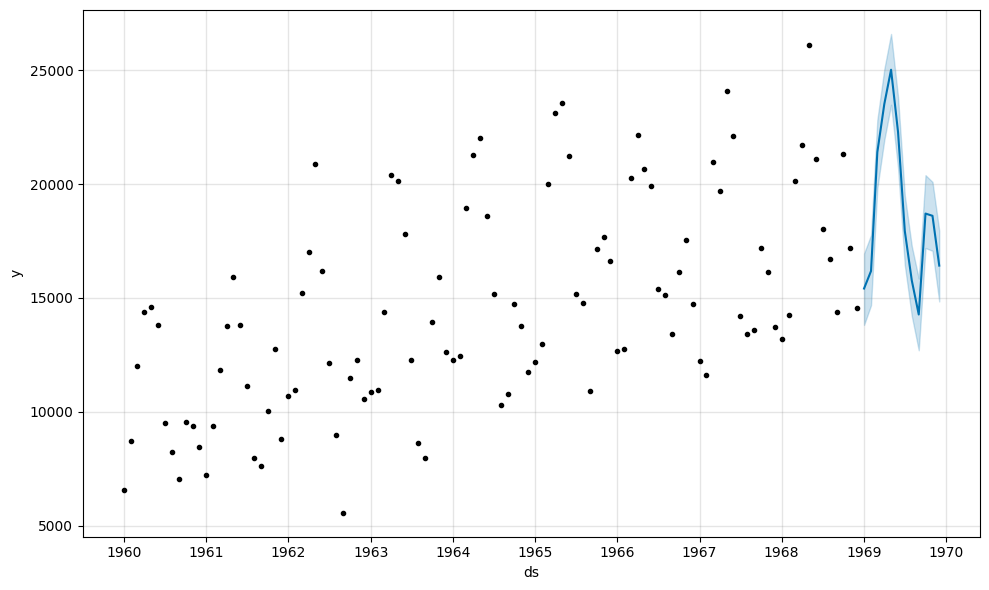

In [71]:
model.plot(forecast)
pyplot.show()

In [72]:
train = df.drop(df.index[-12:])
y_true = df['y'][-12:].values

model = Prophet()
model.fit(train)

11:21:10 - cmdstanpy - INFO - Chain [1] start processing
11:21:10 - cmdstanpy - INFO - Chain [1] done processing


In [73]:
last_1year = list()
for i in range(1, 13):
    last_1year.append(['1968-%02d' % i])

last_1year = pd.DataFrame(last_1year, columns = ['ds'])
last_1year['ds'] = pd.to_datetime(last_1year['ds'])

In [74]:
forecast = model.predict(last_1year)
y_pred = forecast['yhat'].values

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_true, y_pred)
print('MAE: %.3f' % mae)

MAE: 1336.813


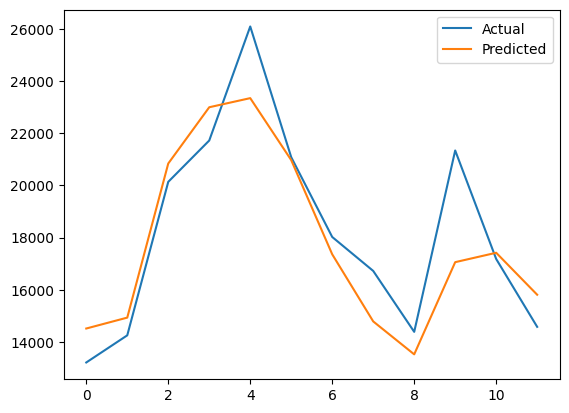

In [75]:
pyplot.plot(y_true, label = 'Actual')
pyplot.plot(y_pred, label = 'Predicted')
pyplot.legend()
pyplot.show()